In [1]:
import torch
import sys
import PIL.Image
import numpy as np
from dataclasses import dataclass
from typing import List, Optional, Union, Callable
from diffusers.pipelines.stable_diffusion.pipeline_output import StableDiffusionPipelineOutput

sys.path.append("./code")
from pipeline_rf import RectifiedFlowPipeline
# from sam2.build_sam import build_sam2
# from sam2.sam2_image_predictor import SAM2ImagePredictor

# checkpoint = "/Data/yiming.chen/sam2/checkpoints/sam2.1_hiera_large.pt"
# model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"
# predictor = SAM2ImagePredictor(build_sam2(model_cfg, checkpoint))


In [2]:
from dataclasses import dataclass, replace, field
from typing import List, Optional, Union, Callable
import copy
import torch
import torch.nn.functional as F

from diffusers.pipelines.stable_diffusion.pipeline_output import StableDiffusionPipelineOutput

# Import drag utilities
from drag_utils import (
    override_unet_forward, 
    drag_rf_update, 
    forward_unet_features,
    point_tracking,
    check_handle_reach_target,
)


@dataclass
class RectifiedFlowPipelineOutput(StableDiffusionPipelineOutput):
    """Output class for Rectified Flow pipelines."""
    images: Union[List[PIL.Image.Image], np.ndarray]
    initial_latents: Optional[torch.FloatTensor]
    intermediate_latents: Optional[List[torch.FloatTensor]]
    nsfw_content_detected: Optional[List[bool]]


@dataclass
class InferenceState:
    initial_latent: torch.FloatTensor
    latent: torch.FloatTensor
    timesteps: list
    i: int
    dt: float
    prompt_embeds: torch.FloatTensor
    guidance_scale: float
    do_cfg: bool
    device: torch.device
    intermediate_latents: Optional[List[torch.FloatTensor]]
    
    def reset(self):
        self.latent = self.initial_latent.clone()
        self.intermediate_latents = []
        self.i = 0
    
    def clone(self):
        return replace(self, 
                       latent=self.latent.clone(),
                       intermediate_latents=list(self.intermediate_latents) if self.intermediate_latents else [])


class RectifiedFlowStateMachine(RectifiedFlowPipeline):
    def __init__(self, vae, text_encoder, tokenizer, unet, scheduler, safety_checker, feature_extractor, requires_safety_checker=False):
        super().__init__(
            vae=vae,
            text_encoder=text_encoder,
            tokenizer=tokenizer,
            unet=unet,
            scheduler=scheduler,
            safety_checker=safety_checker,
            feature_extractor=feature_extractor,
            requires_safety_checker=requires_safety_checker
        )
    
    def modify_unet_forward(self):
        """Override UNet forward to return intermediate features for drag."""
        self.unet.forward = override_unet_forward(self.unet)
    
    def get_text_embeddings(self, prompt):
        """Get text embeddings for a given prompt."""
        text_input = self.tokenizer(
            prompt,
            padding="max_length",
            max_length=self.tokenizer.model_max_length,
            truncation=True,
            return_tensors="pt"
        )
        text_embeddings = self.text_encoder(text_input.input_ids.to(self._execution_device))[0]
        return text_embeddings
    
    @torch.no_grad()
    def prepare_state(
        self,
        prompt=None,
        height=None,
        width=None,
        num_inference_steps=50,
        guidance_scale=2.5,
        negative_prompt=None,
        num_images_per_prompt=1,
        generator=None,
        latents=None,
        prompt_embeds=None,
        negative_prompt_embeds=None,
        cross_attention_kwargs=None,
        store_all_intermediate_latents=False,
    ):
        height = height or self.unet.config.sample_size * self.vae_scale_factor
        width = width or self.unet.config.sample_size * self.vae_scale_factor

        device = self._execution_device
        do_cfg = guidance_scale > 1.0

        # batch size
        if prompt is not None and isinstance(prompt, str):
            batch_size = 1
        elif isinstance(prompt, list):
            batch_size = len(prompt)
        else:
            batch_size = prompt_embeds.shape[0]

        # encode prompt
        prompt_embeds, negative_prompt_embeds = self.encode_prompt(
            prompt,
            device,
            num_images_per_prompt,
            do_cfg,
            negative_prompt,
            prompt_embeds=prompt_embeds,
            negative_prompt_embeds=negative_prompt_embeds,
            lora_scale=(
                cross_attention_kwargs.get("scale", None)
                if cross_attention_kwargs else None
            ),
        )

        if do_cfg:
            prompt_embeds = torch.cat([negative_prompt_embeds, prompt_embeds])

        # timesteps & dt
        timesteps = [(1. - i / num_inference_steps) * 1000. for i in range(num_inference_steps)]
        dt = 1.0 / num_inference_steps

        # latents
        latents = self.prepare_latents(
            batch_size * num_images_per_prompt,
            self.unet.config.in_channels,
            height,
            width,
            prompt_embeds.dtype,
            device,
            generator,
            latents,
        )
        
        return InferenceState(
            initial_latent=latents.detach().clone(),
            latent=latents,
            timesteps=timesteps,
            i=0,
            dt=dt,
            prompt_embeds=prompt_embeds,
            guidance_scale=guidance_scale,
            do_cfg=do_cfg,
            device=device,
            intermediate_latents=[] if store_all_intermediate_latents else None
        )
        
    @torch.no_grad()
    def infer_from_state(
        self,
        state: InferenceState,
        until: Optional[int] = None,
        callback: Optional[Callable[[int, float, torch.FloatTensor], None]] = None,
    ):
        """Run inference from current state until specified step."""
        while state.i < (len(state.timesteps) if until is None else until):
            t = state.timesteps[state.i]

            latent_model_input = (torch.cat([state.latent] * 2) if state.do_cfg else state.latent)

            vec_t = torch.ones((latent_model_input.shape[0],), device=state.device) * t

            v_pred = self.unet(
                latent_model_input,
                vec_t,
                encoder_hidden_states=state.prompt_embeds
            )
            # Handle both tuple and tensor returns
            if isinstance(v_pred, tuple):
                v_pred = v_pred[0]
            elif hasattr(v_pred, 'sample'):
                v_pred = v_pred.sample

            if state.do_cfg:
                v_pred_neg, v_pred_text = v_pred.chunk(2)
                v_pred = v_pred_neg + state.guidance_scale * (v_pred_text - v_pred_neg)

            state.latent = state.latent + state.dt * v_pred

            if state.intermediate_latents is not None:
                state.intermediate_latents.append(state.latent.detach())

            if callback is not None:
                callback(state.i, t, state.latent)

            state.i += 1

        return state


In [3]:
# ============================================================
# Drag Configuration and Helper Functions
# ============================================================

from types import SimpleNamespace
from einops import rearrange


def convert_points(points, full_h, full_w, sup_res_h, sup_res_w):
    """Convert pixel coordinates to feature map coordinates."""
    handle_points, target_points = [], []
    for idx, point in enumerate(points):
        # points are (x, y) from UI, convert to (row, col) = (y, x)
        cur_point = torch.tensor([point[1] / full_h * sup_res_h, 
                                   point[0] / full_w * sup_res_w])
        cur_point = torch.round(cur_point)
        if idx % 2 == 0:
            handle_points.append(cur_point)
        else:
            target_points.append(cur_point)
    return handle_points, target_points


def run_rf_drag(
    pipe,
    state,  # InferenceState
    mask: np.ndarray,          # H x W, values in [0, 255]
    points: list,              # [(x1,y1), (x2,y2), ...] alternating handle/target
    drag_step: int = 20,       # Which step to apply drag
    n_pix_step: int = 80,      # Number of optimization steps
    lr: float = 0.01,          # Learning rate for latent optimization
    lam: float = 0.1,          # Background regularization weight
    unet_feature_idx: list = [3],  # Which UNet layer to use for features
    sup_res_h: int = 256,      # Feature resolution height
    sup_res_w: int = 256,      # Feature resolution width
    r_m: int = 1,              # Motion supervision radius
    r_p: int = 3,              # Point tracking search radius
    end_step: int = 50,        # Final inference step
):
    """
    Run drag editing on a RectifiedFlow generation.
    
    Unlike DragDiffusion, we don't invert an image. Instead:
    1. Run generation until drag_step
    2. Apply drag optimization at that step
    3. Continue generation to end
    
    Returns:
        Final generated image as PIL.Image, and the final state
    """
    # Create args namespace for drag_rf_update
    args = SimpleNamespace(
        n_pix_step=n_pix_step,
        lr=lr,
        lam=lam,
        unet_feature_idx=unet_feature_idx,
        sup_res_h=sup_res_h,
        sup_res_w=sup_res_w,
        r_m=r_m,
        r_p=r_p,
    )
    
    # Reset state and run until drag_step
    state.reset()
    state = pipe.infer_from_state(state, until=drag_step)

    drag_code_vis = pipe.decode_latents(state.latent, disable_safety_checker=True)[0][0]
    
    # Prepare mask: convert to tensor [1, 1, H, W]
    mask_tensor = torch.from_numpy(mask).float() / 255.0
    mask_tensor[mask_tensor > 0.0] = 1.0
    mask_tensor = mask_tensor.unsqueeze(0).unsqueeze(0).to(state.device)
    mask_tensor = F.interpolate(mask_tensor, (sup_res_h, sup_res_w), mode='nearest')
    
    # Get current image dimensions (latent * 8)
    full_h = state.latent.shape[2] * 8
    full_w = state.latent.shape[3] * 8
    
    # Convert points to feature coordinates
    handle_points, target_points = convert_points(
        points, full_h, full_w, sup_res_h, sup_res_w
    )
    
    # Get current timestep value
    t = state.timesteps[state.i - 1] if state.i > 0 else state.timesteps[0]
    
    # Get text embeddings (without CFG for drag)
    if state.do_cfg:
        # Take only the positive prompt embeddings
        text_embeds = state.prompt_embeds.chunk(2)[1]
    else:
        text_embeds = state.prompt_embeds
    
    # Apply drag update
    print(f"Applying drag at step {state.i} (t={t:.1f})")
    updated_latent = drag_rf_update(
        pipe=pipe,
        latent=state.latent,
        t=t,
        prompt_embeds=text_embeds,
        handle_points=handle_points,
        target_points=target_points,
        mask=mask_tensor,
        args=args,
        dt=state.dt,
    )
    
    # Update state with dragged latent
    state.latent = updated_latent

    # Continue inference to end
    state = pipe.infer_from_state(state, until=drag_step)
    drag_code_vis_after = pipe.decode_latents(state.latent, disable_safety_checker=True)[0][0]

    state = pipe.infer_from_state(state, until=end_step)

    # Decode final latent to image
    # decode_latents returns (list_of_pil_images, has_nsfw_concept)
    image = pipe.decode_latents(state.latent, disable_safety_checker=True)[0][0]
    
    return image, drag_code_vis, drag_code_vis_after, state

In [4]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F


def make_latent_drag_ui(pipe, base_state, t_drag=10, t_end=50, warp_fn=None):
    """
    base_state: prepare_state(...) 得到的 state（尚未 infer 或可 reset）
    """
    dx_slider = widgets.FloatSlider(value=0.0, min=-32, max=32, step=1.0, description="dx(lat)")
    dy_slider = widgets.FloatSlider(value=0.0, min=-32, max=32, step=1.0, description="dy(lat)")
    run_btn = widgets.Button(description="Run Drag")
    out = widgets.Output()

    def run_once(_=None):
        with out:
            clear_output(wait=True)

            s = base_state
            s.reset()
            s = pipe.infer_from_state(s, until=t_end)
            image_before = pipe.decode_latents(s.latent, disable_safety_checker=True)[0][0]

            s.reset()
            s = pipe.infer_from_state(s, until=t_drag)
            latent_before = pipe.decode_latents(s.latent, disable_safety_checker=True)[0][0]

            # 2) apply warp immediately (preview)
            dx = float(dx_slider.value)
            dy = float(dy_slider.value)
            if warp_fn is not None:
                s.latent = warp_fn(s.latent, dx=dx, dy=dy)

            latent_after = pipe.decode_latents(s.latent, disable_safety_checker=True)[0][0]

            # 3) continue to end
            s = pipe.infer_from_state(s, until=t_end)
            img_final = pipe.decode_latents(s.latent, disable_safety_checker=True)[0][0]

            # 4) show 3 images
            plt.figure(figsize=(15, 5))
            plt.subplot(1, 4, 1); plt.imshow(image_before); plt.title(f"Original (t={t_drag})"); plt.axis("off")
            plt.subplot(1, 4, 2); plt.imshow(latent_before); plt.title(f"Before (t={t_drag})"); plt.axis("off")
            plt.subplot(1, 4, 3); plt.imshow(latent_after);  plt.title(f"After warp (dx={dx}, dy={dy})"); plt.axis("off")
            plt.subplot(1, 4, 4); plt.imshow(img_final);  plt.title(f"Final (t={t_end})"); plt.axis("off")

    run_btn.on_click(run_once)
    ui = widgets.VBox([widgets.HBox([dx_slider, dy_slider, run_btn]), out])
    display(ui)

    # initial run
    run_once()


In [5]:
# Load the pipeline and modify UNet for feature extraction
pipe = RectifiedFlowStateMachine.from_pretrained(
    "XCLiu/2_rectified_flow_from_sd_1_5", 
    torch_dtype=torch.bfloat16, 
    device_map="cuda"
)
pipe.safety_checker = None

# IMPORTANT: Override UNet forward to return intermediate features
pipe.modify_unet_forward()
print("Pipeline loaded and UNet modified for feature extraction")


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /Data/yiming.chen/huggingface/hub/models--XCLiu--2_rectified_flow_from_sd_1_5/snapshots/934962eb1054b67883fabb3e0860b851baf31142/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /Data/yiming.chen/huggingface/hub/models--XCLiu--2_rectified_flow_from_sd_1_5/snapshots/934962eb1054b67883fabb3e0860b851baf31142/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Pipeline loaded and UNet modified for feature extraction


/Data/yiming.chen/envs/py311/lib/python3.11/site-packages/diffusers/loaders/lora_pipeline.py:5501: FutureWarning: `LoraLoaderMixin` is deprecated and will be removed in version 1.0.0. LoraLoaderMixin is deprecated and this will be removed in a future version. Please use `StableDiffusionLoraLoaderMixin`, instead.
  deprecate("LoraLoaderMixin", "1.0.0", deprecation_message)


In [6]:
def warp_latent_translate_gaussian(
    latent: torch.Tensor,
    dx: float,
    dy: float,
    noise_std: float = 1.0,
) -> torch.Tensor:
    """
    latent: (B, C, H, W)
    dx, dy: pixel shift in latent coordinates
    noise_std: std of gaussian noise for padding area
    """
    B, C, H, W = latent.shape
    device = latent.device
    dtype = latent.dtype

    # base grid in [-1,1]
    grid_y, grid_x = torch.meshgrid(
        torch.linspace(-1, 1, H, device=device),
        torch.linspace(-1, 1, W, device=device),
        indexing="ij"
    )
    grid = torch.stack([grid_x, grid_y], dim=-1)[None]  # (1,H,W,2)

    # pixel -> normalized shift
    shift_x = dx / (W / 2.0)
    shift_y = dy / (H / 2.0)

    shift = torch.zeros_like(grid)
    shift[..., 0] = shift_x
    shift[..., 1] = shift_y

    grid = grid + shift
    grid = grid.repeat(B, 1, 1, 1)

    # grid_sample (still zeros padding)
    warped = F.grid_sample(
        latent,
        grid,
        mode="bilinear",
        padding_mode="zeros",
        align_corners=True
    )

    # === 关键：找出越界区域 ===
    valid_x = (grid[..., 0] >= -1.0) & (grid[..., 0] <= 1.0)
    valid_y = (grid[..., 1] >= -1.0) & (grid[..., 1] <= 1.0)
    valid = (valid_x & valid_y).float()  # (B,H,W)

    valid = valid[:, None, :, :]  # (B,1,H,W)

    # Gaussian noise
    noise = torch.randn_like(warped) * noise_std

    # replace invalid area with noise
    warped = warped * valid + noise * (1.0 - valid)
    return warped


In [7]:
state = pipe.prepare_state(
    prompt="a photo of a shoe on the grass",
    height=512,
    width=512,
    num_inference_steps=50,
    guidance_scale=2.5,
    negative_prompt=None,
    num_images_per_prompt=1,
    generator=None,
    prompt_embeds=None,
    store_all_intermediate_latents=False,
)

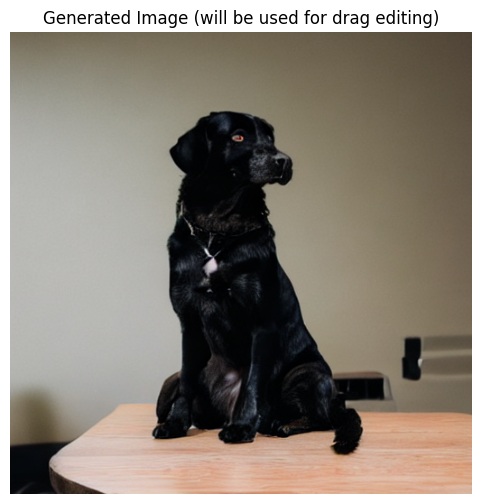

In [8]:
# ============================================================
# Interactive Drag UI
# ============================================================
from widget_editor import MaskPainter, PointArrowEditor
import matplotlib.pyplot as plt

# First, generate a base image
prompt = "a photo of a dog sitting on a table"
state = pipe.prepare_state(
    prompt=prompt,
    height=512,
    width=512,
    num_inference_steps=50,
    guidance_scale=2.5,
    store_all_intermediate_latents=False,
)

# Generate the initial image
state.reset()
state = pipe.infer_from_state(state, until=50)
# decode_latents returns (list_of_pil_images, has_nsfw_concept)
base_image_pil = pipe.decode_latents(state.latent, disable_safety_checker=True)[0][0]

# Display the base image
plt.figure(figsize=(6, 6))
plt.imshow(base_image_pil)
plt.title("Generated Image (will be used for drag editing)")
plt.axis("off")
plt.show()

# Convert PIL to numpy for widget editor
base_image_np = np.array(base_image_pil)

In [9]:
# Step 1: Paint the mask (region to drag)
# Draw on the canvas to mark the region you want to drag
painter = MaskPainter(base_image_np, brush_radius=20, fill_style="rgba(255, 0, 0, 0.4)")
painter.show()

Canvas(height=512, width=512)

In [10]:
# Step 2: Select handle and target points
# Click to add source points (red), then click again for target points (blue)
# Each pair defines a drag: source -> target
editor = PointArrowEditor(base_image_np)
editor.show()

Canvas(height=512, width=512)

In [17]:
# Step 3: Get mask and points, then run drag
mask = painter.get_mask()
points = editor.get_points()

print(f"Mask sum: {mask.sum()}")
print(f"Points: {points}")
print(f"Number of handle-target pairs: {len(points) // 2}")

Mask sum: 19046
Points: [(291, 153), (279, 186), (268, 144), (250, 182)]
Number of handle-target pairs: 2


Applying drag at step 10 (t=820.0)


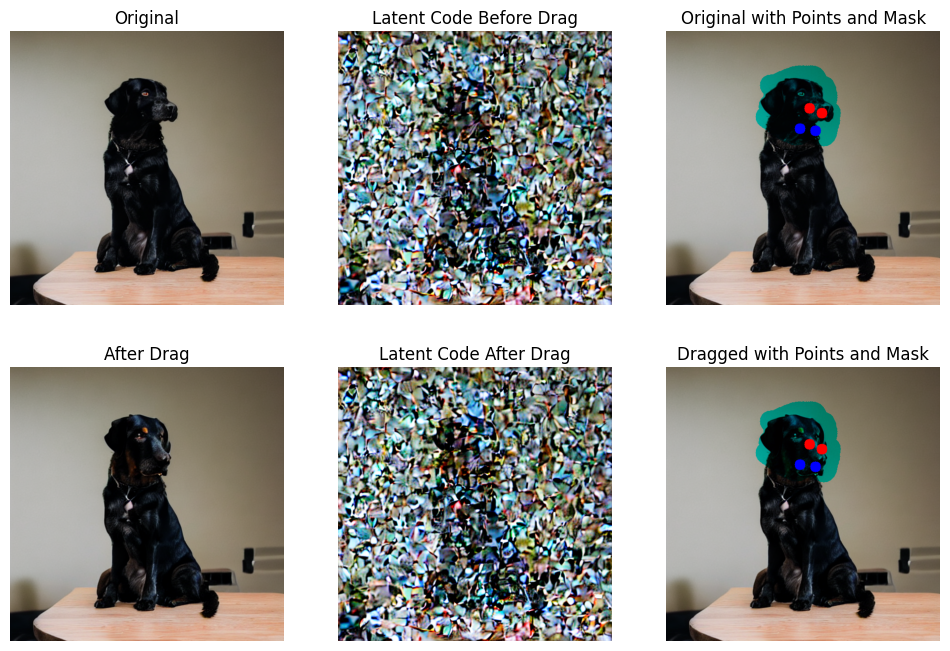

In [ ]:
# Step 4: Run drag editing
# Drag parameters
drag_config = {
    "drag_step": 10,       # Which step to apply drag (earlier = more effect)
    "n_pix_step": 60,      # Number of optimization iterations
    "lr": 0.01,            # Learning rate
    "lam": 0.1,            # Background regularization
    "unet_feature_idx": [3],  # UNet layer for features (3 = 64x64)
    "sup_res_h": 256,      # Feature supervision resolution
    "sup_res_w": 256,
    "r_m": 1,              # Motion supervision radius
    "r_p": 3,              # Point tracking search radius
}

# Run the drag
dragged_image, drag_code_vis, drag_code_vis_after, state = run_rf_drag(
    pipe=pipe,
    state=state,
    mask=mask * 255,  # Convert to 0-255 range
    points=points,
    **drag_config,
)


# Overlay points and mask on original and dragged images
from widget_editor import overlay_points_and_mask
overlayed_original = overlay_points_and_mask(base_image_np, points, mask)
overlayed_dragged = overlay_points_and_mask(dragged_image, points, mask)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
# 第一列
axes[0, 0].imshow(base_image_pil)
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

axes[1, 0].imshow(dragged_image)
axes[1, 0].set_title("After Drag")
axes[1, 0].axis("off")

# 第二列
axes[0, 1].imshow(drag_code_vis)
axes[0, 1].set_title("Latent Code Before Drag")
axes[0, 1].axis("off")

axes[1, 1].imshow(drag_code_vis_after)
axes[1, 1].set_title("Latent Code After Drag")
axes[1, 1].axis("off")

# 第三列
axes[0, 2].imshow(overlayed_original)
axes[0, 2].set_title("Original with Points and Mask")
axes[0, 2].axis("off")

axes[1, 2].imshow(overlayed_dragged)
axes[1, 2].set_title("Dragged with Points and Mask")
axes[1, 2].axis("off")

plt.show()

In [14]:
# ============================================================
# Optional: Train LoRA on the base image for better reconstruction
# ============================================================
from lora_utils import RFLoraConfig, train_rf_lora, load_rf_lora, unload_rf_lora
# Configure LoRA training
lora_config = RFLoraConfig(
    lora_rank=16,
    lora_alpha=16,
    lora_dropout=0.0,
    target_modules=("to_q", "to_k", "to_v", "to_out.0"),
    lora_steps=20,
    lora_lr=1e-4,
    lora_batch_size=4,
    lora_save_dir="lora_tmp/rf_lora/",
    seed=42,
)

# Completely remove LoRA and return to base model
pipe = unload_rf_lora(pipe)

# Train LoRA on the base image
# Note: This fine-tunes the model on your specific image for better drag results
pipe = train_rf_lora(
    pipe=pipe,
    image=base_image_pil,  # The PIL image we generated earlier
    prompt=prompt,         # The prompt used to generate it
    config=lora_config,
)

print("LoRA training complete! The pipeline now uses the fine-tuned weights.")

No LoRA to unload.
trainable params: 3,188,736 || all params: 862,709,700 || trainable%: 0.3696


Training LoRA:   5%|▌         | 1/20 [00:00<00:07,  2.42it/s]

Step 0/20, Loss: 4.342348


Training LoRA: 100%|██████████| 20/20 [00:07<00:00,  2.54it/s]

LoRA weights saved to lora_tmp/rf_lora/
LoRA training complete! The pipeline now uses the fine-tuned weights.


Applying drag at step 20 (t=620.0)


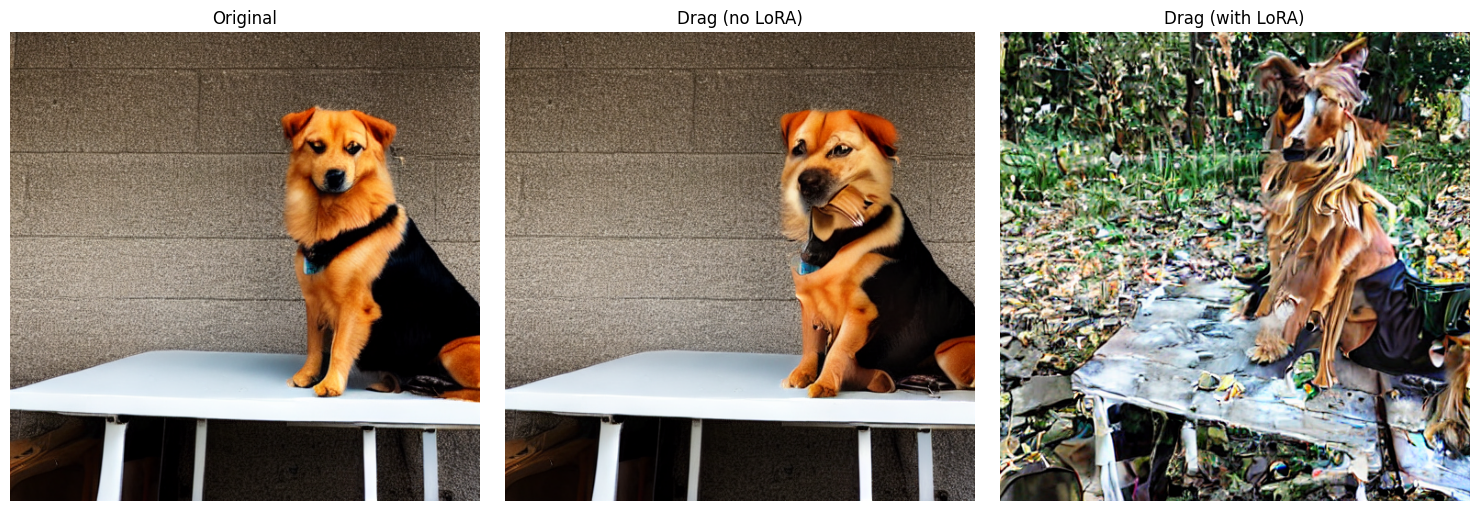

In [15]:
# After LoRA training, run drag again with the fine-tuned model
# The results should be more faithful to the original image

dragged_image_lora, final_state_lora = run_rf_drag(
    pipe=pipe,
    state=state,
    mask=mask * 255,
    points=points,
    **drag_config,
)

# Compare results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(base_image_pil)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(dragged_image)
axes[1].set_title("Drag (no LoRA)")
axes[1].axis("off")

axes[2].imshow(dragged_image_lora)
axes[2].set_title("Drag (with LoRA)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Alternative: Load existing LoRA weights (skip training)
# ============================================================
# If you've already trained LoRA and want to reload it:
#
# from lora_utils import load_rf_lora, enable_rf_lora, disable_rf_lora, unload_rf_lora
#
# # Load saved LoRA weights
# pipe = load_rf_lora(pipe, "lora_tmp/rf_lora/")
#
# # You can also toggle LoRA on/off:
# disable_rf_lora(pipe)  # Use base model only (LoRA still in memory)
# enable_rf_lora(pipe)   # Re-enable LoRA
#
# # To completely remove LoRA (e.g., before training a new one):
# pipe = unload_rf_lora(pipe)  # Returns to pure base model